# Kernel Methods: 1D Non-Linear Regression

## Importing the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import linear_kernel, polynomial_kernel, rbf_kernel

## Creating a function to visualize the model predictions

In [2]:
def visualize_predictions(X_test, model):

    y_pred = model.predict(X_test)

    plt.scatter(x_train, y_train, color='blue')  # Plotting training data
    plt.plot(x_test, y_pred, color='red')  # Plotting predictions
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Model Predictions')
    plt.show()

In [3]:
# Setting a random seed for reproducibility
np.random.seed(42)

## Generating random training data between -5 and 5


In [4]:
m = 100
x_train = 10 * np.random.rand(m) - 5

## Generating a smooth test set for evaluation

In [5]:
x_test = np.linspace(-5, 5, 100).reshape(-1, 1)

## Defining the underlying function

In [6]:
def underlying_function(x):

    return np.sin(x) + 0.5 * np.cos(2 * x) + 2 * np.sin(3 * x)

In [7]:
# Adding noise to the training labels
y_train = underlying_function(x_train) + 0.5 * np.random.randn(m)

# Reshaping for compatibility with sklearn
x_train = x_train.reshape(-1, 1)

## Plotting the training data

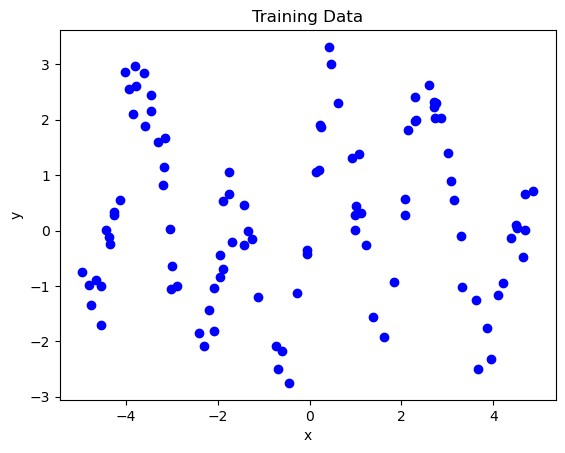

In [8]:
plt.scatter(x_train, y_train, color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data')
plt.show()

# Standard Linear Regression

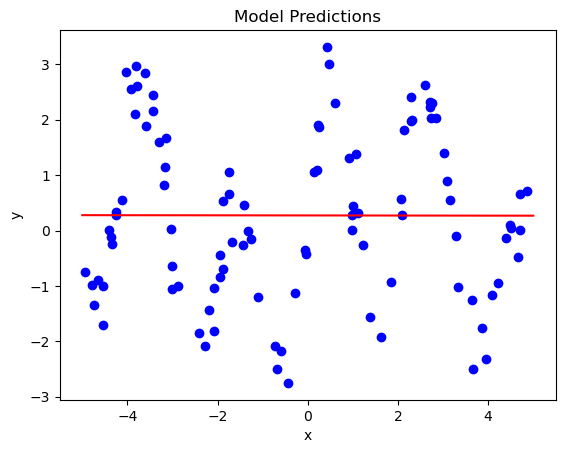

In [9]:
# Fitting a standard linear regression model
lin_model = Ridge(alpha=0)  # Ridge with alpha=0 is equivalent to standard linear regression
lin_model.fit(x_train, y_train)

# Visualizing the predictions
visualize_predictions(x_test, lin_model)

# Kernel Trick for Linear Regression

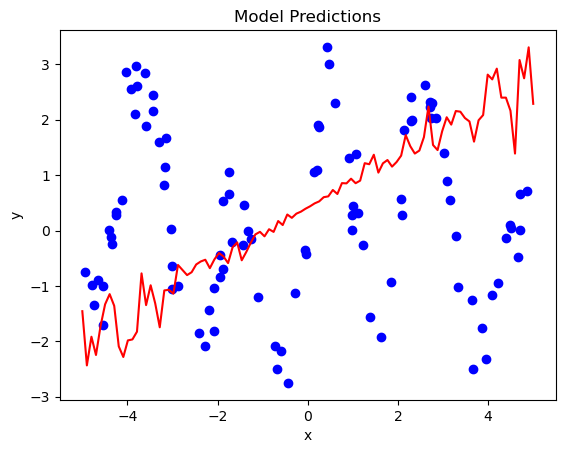

In [10]:
# Defining a custom linear kernel function
def custom_linear_kernel(X, Y):

    return np.dot(X, Y.T)

# Computing the kernel matrices for training and testing data
K_train_linear = custom_linear_kernel(x_train, x_train)
K_test_linear = custom_linear_kernel(x_test, x_train)

# Training the Ridge regression model on the linear kernel matrix
linear_kernel_model = Ridge(alpha=0)
linear_kernel_model.fit(K_train_linear, y_train)

# Visualizing the predictions using the linear kernel model
visualize_predictions(K_test_linear, linear_kernel_model)

# Polynomial kernel

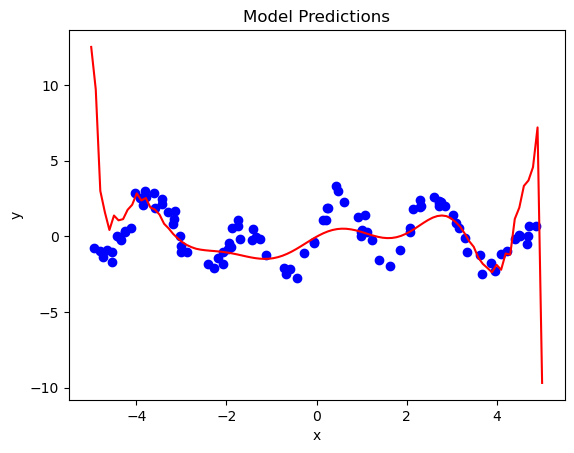

In [11]:
# Defining a custom polynomial kernel function
def custom_polynomial_kernel(X, Y, degree=3):

    return (np.dot(X, Y.T) + 1) ** degree

# Setting the degree for the polynomial kernel
degree = 12

# Computing the polynomial kernel matrices
K_train_poly = custom_polynomial_kernel(x_train, x_train, degree)
K_test_poly = custom_polynomial_kernel(x_test, x_train, degree)

# Adding a small regularization term to avoid singular matrices
K_train_poly += 1e-9 * np.eye(m)

# Training the Ridge regression model on the polynomial kernel
poly_kernel_model = Ridge(alpha=0)
poly_kernel_model.fit(K_train_poly, y_train)

# Visualizing the predictions using the polynomial kernel model
visualize_predictions(K_test_poly, poly_kernel_model)

# Gaussian kernel

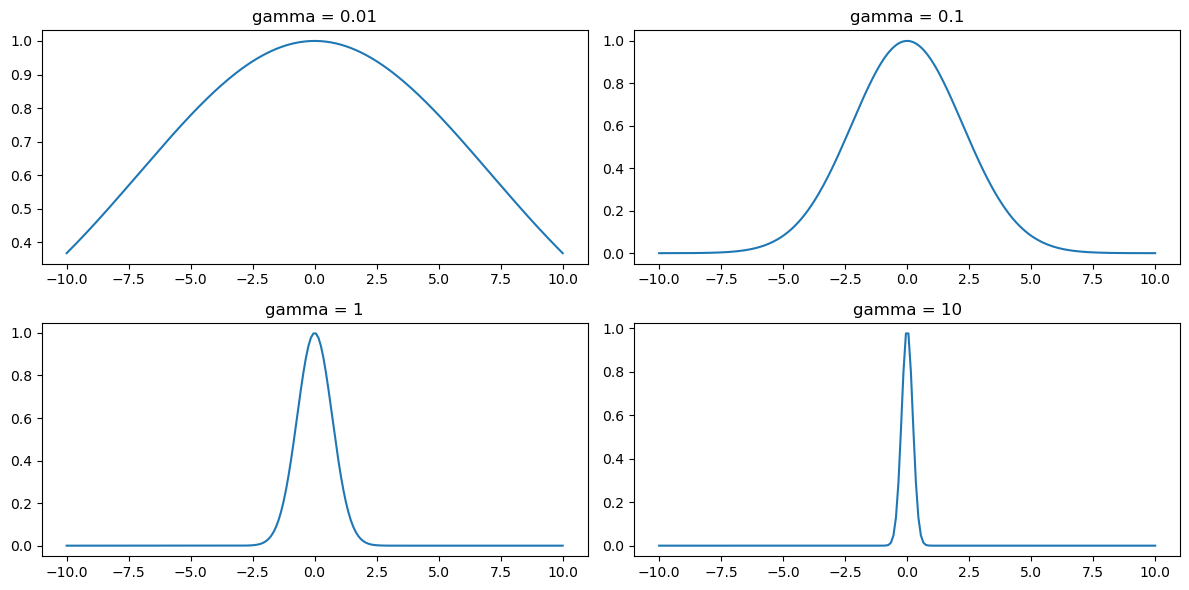

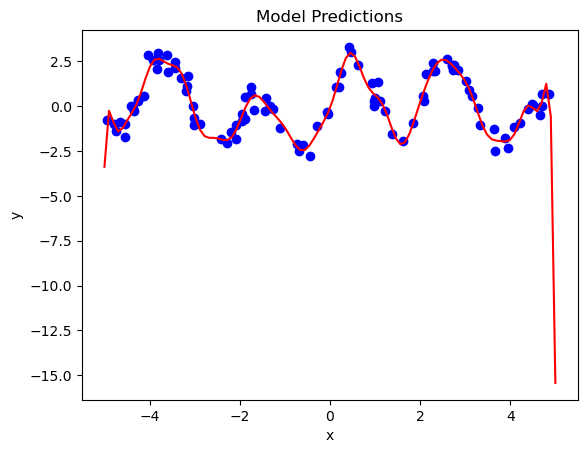

In [12]:
# Defining a custom Gaussian (RBF) kernel function
def custom_gaussian_kernel(X, Y, gamma):

    sq_dists = -2 * np.dot(X, Y.T) + np.sum(Y ** 2, axis=1) + np.sum(X ** 2, axis=1)[:, np.newaxis]
    return np.exp(-gamma * sq_dists)

# Setting gamma values for demonstration
gamma_values = [0.01, 0.1, 1, 10]

# Plotting Gaussian kernel similarity for different gamma values
x_values = np.linspace(-10, 10, 200).reshape(-1, 1)
zero_vector = np.zeros((1, 1))

plt.figure(figsize=(12, 6))

for idx, gamma in enumerate(gamma_values):

    plt.subplot(2, 2, idx + 1)
    k_values = custom_gaussian_kernel(x_values, zero_vector, gamma)
    plt.plot(x_values, k_values)
    plt.title(f'gamma = {gamma}')

plt.tight_layout()
plt.show()

# Training a model using Gaussian kernel with a specific gamma value
gamma = 1

K_train_gauss = custom_gaussian_kernel(x_train, x_train, gamma) + 1e-9 * np.eye(m)
K_test_gauss = custom_gaussian_kernel(x_test, x_train, gamma)

gaussian_kernel_model = Ridge(alpha=0)
gaussian_kernel_model.fit(K_train_gauss, y_train)

# Visualizing the predictions using the Gaussian kernel model
visualize_predictions(K_test_gauss, gaussian_kernel_model)

# Linear Regression with Gaussian Kernel and Regularization

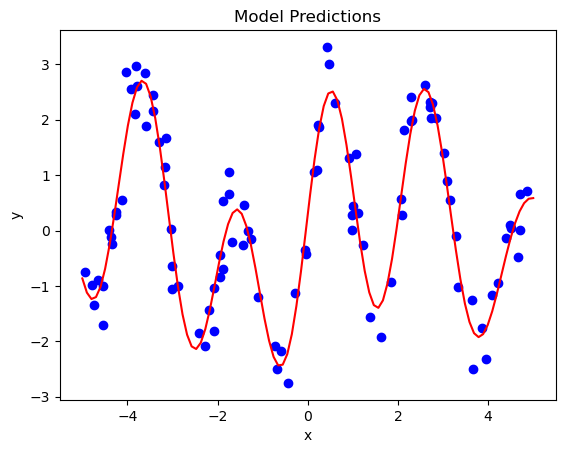

In [13]:
# Implementing Ridge Regression with Gaussian kernel using sklearn
from sklearn.kernel_ridge import KernelRidge

# Setting the regularization parameter and gamma for Gaussian kernel
lambda_val = 0.01
gamma = 0.5

# Training Kernel Ridge Regression model
ridge_gaussian_model = KernelRidge(alpha=lambda_val, kernel='rbf', gamma=gamma)
ridge_gaussian_model.fit(x_train, y_train)

# Visualizing the predictions using the Gaussian kernel with regularization
visualize_predictions(x_test, ridge_gaussian_model)

# 2D Non-Linear Classification

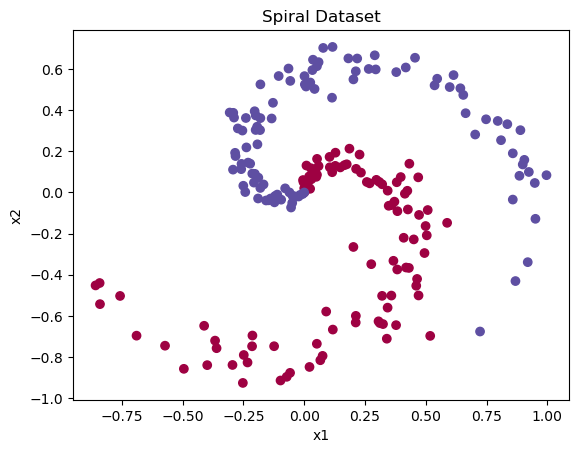

In [14]:
# Generating a 2D spiral dataset for classification
N = 100  # Samples per class
D = 2  # Dimensionality
K = 2  # Number of classes

X_spiral = np.zeros((N * K, D))
y_spiral = np.zeros(N * K, dtype='uint8')

for j in range(K):

    ix = range(N * j, N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.3
    X_spiral[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y_spiral[ix] = j

# Visualizing the dataset
plt.scatter(X_spiral[:, 0], X_spiral[:, 1], c=y_spiral, cmap=plt.cm.Spectral)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Spiral Dataset')
plt.show()

# Plotting Setup

In [15]:
# Creating a mesh grid for plotting decision boundaries
h = 0.05
x_min, x_max = X_spiral[:, 0].min() - 0.5, X_spiral[:, 0].max() + 0.5
y_min, y_max = X_spiral[:, 1].min() - 0.5, X_spiral[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

X_test_spiral = np.c_[xx.ravel(), yy.ravel()]

# Defining a function to plot decision boundaries for classification models
def plot_decision_boundary(X_test, model):

    Z = model.predict(X_test).reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X_spiral[:, 0], X_spiral[:, 1], c=y_spiral, cmap=plt.cm.Spectral)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Decision Boundary')
    plt.show()

# Kernelized Logistic Regression

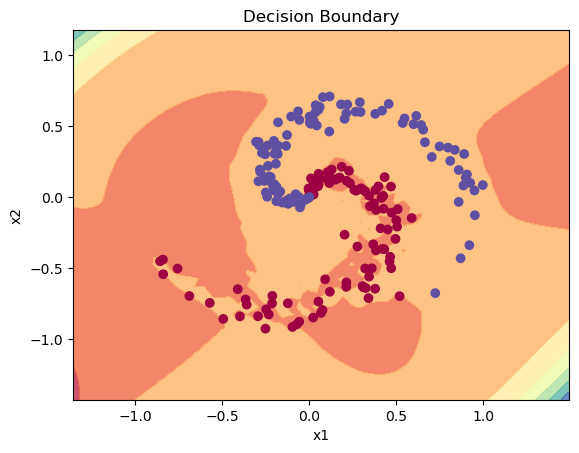

In [16]:
# Defining gamma for the RBF kernel
gamma = 0.1

# Computing the RBF kernel matrices for the spiral dataset
K_train_rbf = custom_gaussian_kernel(X_spiral, X_spiral, gamma)
K_test_rbf = custom_gaussian_kernel(X_test_spiral, X_spiral, gamma)

# Training logistic regression on the RBF kernel matrix
logistic_model = Ridge(alpha=0)  # Using Ridge as a proxy for logistic regression with custom kernel
logistic_model.fit(K_train_rbf, y_spiral)

# Plotting the decision boundary
plot_decision_boundary(K_test_rbf, logistic_model)

# Kernelized SVM

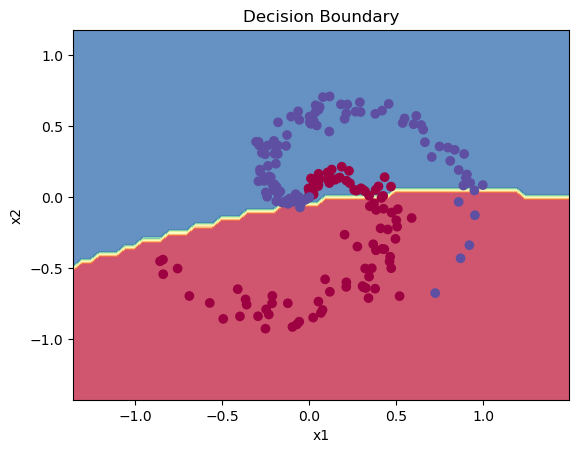

In [17]:
# Training an SVM with RBF kernel using sklearn's SVC
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', gamma=gamma)
svm_model.fit(X_spiral, y_spiral)

# Plotting the decision boundary
plot_decision_boundary(X_test_spiral, svm_model)